## Titanic Survival Prediction using Scikit Learn

In [97]:
# Information of dataset
    # Passengerid : passenger data num
    # survived : 0-died, 1-survived
    # pclass: ticket rank
    # sex : gender
    # name : passenger's name
    # Age : passenger's age'
    # sibsp : siblings & spouse
    # parch : parents & children
    # ticket : ticket num
    # fare : price 
    # cabin : cabin num
    # embarked : settlement port

In [98]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [99]:
# Load data
titanic_df = pd.read_csv('titanic_train.csv')
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [100]:
# Information of data
# RangeIndex : boundary of DataFrame index, can know total row(891)
# column : 12
# dtypes: 2 columns with float64 type, 5 columns with int64 type, 5 columns with object type
    # object : same with string
print('\n ### 학습 데이터 정보 ###\n')
print(titanic_df.info())


 ### 학습 데이터 정보 ###

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [101]:
# Age,Cabin,Embarked contain 714,204,889 non-null values -> contain 177,608,2 Null(NaN) values
    # scikit learn ML algorithm does not approve non-null so have to remove or replace
        # Replace : with mean value('Age'), with standard value('Cabin','Embarked')
titanic_df['Age'].fillna(titanic_df['Age'].mean(),inplace=True)
titanic_df['Cabin'].fillna('N',inplace=True)
titanic_df['Embarked'].fillna('N',inplace=True)
# check if there are null left of not
print('# of NULL in dataset:',titanic_df.isna().sum().sum())

# of NULL in dataset: 0


/var/folders/94/7h5frtys3qgbp8xn922gq0t40000gn/T/ipykernel_98274/1674994551.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].mean(),inplace=True)
/var/folders/94/7h5frtys3qgbp8xn922gq0t40000gn/T/ipykernel_98274/1674994551.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are sett

In [102]:
# Value Counts of obj features
print('Sex 값 분포 :\n',titanic_df['Sex'].value_counts())
print('Cabin 값 분포 :',titanic_df['Cabin'].value_counts())
print('Embarked 값 분포 :',titanic_df['Embarked'].value_counts())

# Cabin might be essential as class is associated with survival rate but it output form is kind of weird : C23 C25 C27 so will only take first char
# .str -> access values of series as strings
titanic_df['Cabin'] = titanic_df['Cabin'].str[:1]
print(titanic_df['Cabin'].head(3))

Sex 값 분포 :
 Sex
male      577
female    314
Name: count, dtype: int64
Cabin 값 분포 : Cabin
N              687
C23 C25 C27      4
G6               4
B96 B98          4
C22 C26          3
              ... 
E34              1
C7               1
C54              1
E36              1
C148             1
Name: count, Length: 148, dtype: int64
Embarked 값 분포 : Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64
0    N
1    C
2    N
Name: Cabin, dtype: object


In [103]:
# How sex affect survival rate
# By comparing Sex and Survived
titanic_df.groupby(['Sex','Survived'])['Survived'].count()


Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

In [104]:
# How sex affect survival rate
# By using barplot() of seaborn
# X-axis: 'Sex' column, Y-axis: 'Survived' column, data: titanic_df
# female: 233 out of 341(74.2%) survived
# male: 109 out of 577(18.8%) survived
sns.barplot(x='Sex',y='Survived',data=titanic_df)

<Axes: xlabel='Sex', ylabel='Survived'>

In [105]:
# How classes affect survival rate (+ include Sex)
# uses hue for additional
# female have not much diff at 1st and 2nd classes but 3rd class female don't survive much
# male of 1st class survived much more compared with 2nd & 3rd classes
sns.barplot(x='Pclass',y='Survived',hue='Sex',data=titanic_df)

<Axes: xlabel='Sex', ylabel='Survived'>

In [106]:
# How age affect survival rate (+ include Sex)
# Female : elderly survived most and others same except child doesn't survive much
def get_category(age):
    cat = ''
    if age<=-1: cat = 'Unknown'
    elif age<=5: cat='Baby'
    elif age<=12: cat='Child'
    elif age<=18: cat='Teenager'
    elif age<=25: cat='Student'
    elif age<=35: cat='Young Adult'
    elif age<=60: cat='Adult'
    else: cat='Elderly'
    return cat
# Figure size
plt.figure(figsize=(10,6))
# names for each column
group_names = ['Unknown','Baby','Child','Teenager','Student','Young Adult','Adult','Elderly']
titanic_df['Age_cat'] = titanic_df['Age'].apply(lambda x:get_category(x))
sns.barplot(x='Age_cat',y='Survived',hue='Sex',data=titanic_df,order=group_names)
# After using, drop the new column
titanic_df.drop('Age_cat',axis=1,inplace=True)

In [107]:
# Encoding necessary obj data (Cabin,Sex,Embarked)
# using LabelEncoder (0 ~ #ofdata-1)
from sklearn.preprocessing import LabelEncoder

def encode_features(dataFrame):
    features = ['Cabin','Sex','Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(dataFrame[feature])
        # .transform() return labels : [0,1,2,..]
        dataFrame[feature] = le.transform(dataFrame[feature])
    return dataFrame

titanic_df = encode_features(titanic_df)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,7,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,7,3


In [108]:
# Data Preprocessing
    # Process Null values
    # Remove unnecessary features
    # Encoding

# Process Null values
# Age,Cabin,Embarked,Fare
def fillNA(df):
    df['Age'].fillna(df['Age'].mean(),inplace=True)
    df['Cabin'].fillna('N',inplace=True)
    df['Embarked'].fillna('N',inplace=True)
    df['Fare'].fillna(0,inplace=True)
    return df

# Remove unnecessary features
# PassengerId,Name,Ticket : string values with no meaning
def drop_features(df):
    df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)
    return df

# Label Encoding
def format_features(df):
    # Take first char of Cabin
    df['Cabin'] = df['Cabin'].str[:1]
    # Encoding
    features = ['Cabin','Sex','Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        # .transform() return labels : [0,1,2,..]
        df[feature] = le.transform(df[feature])
    return df

# Data Preprocess
def transform_features(df):
    df = fillNA(df)
    df = drop_features(df)
    df = format_features(df)
    return df

# Load data
titanic_df = pd.read_csv('titanic_train.csv')
# Label dataset
y_titanic_df = titanic_df['Survived']
# Feature dataset(drop label)
X_titanic_df = titanic_df.drop('Survived',axis=1)

# Data Preprocessing
X_titanic_df = transform_features(X_titanic_df)


/var/folders/94/7h5frtys3qgbp8xn922gq0t40000gn/T/ipykernel_98274/4082348162.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)
/var/folders/94/7h5frtys3qgbp8xn922gq0t40000gn/T/ipykernel_98274/4082348162.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

In [109]:
# Splitting into train & test data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_titanic_df,y_titanic_df,test_size=0.2,random_state=11)
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
333,3,1,16.0,2,0,18.0000,7,3
662,1,1,47.0,0,0,25.5875,4,3
382,3,1,32.0,0,0,7.9250,7,3
331,1,1,45.5,0,0,28.5000,2,3
149,2,1,42.0,0,0,13.0000,7,3
...,...,...,...,...,...,...,...,...
269,1,0,35.0,0,0,135.6333,2,3
337,1,0,41.0,0,0,134.5000,4,0
91,3,1,20.0,0,0,7.8542,7,3
80,3,1,22.0,0,0,9.0000,7,3


In [110]:
# Train(fit), Predict, Test(accuracy) using DecisionTree, RandomForest, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create model
dt_clf = DecisionTreeClassifier()
rf_clf = RandomForestClassifier()
lr_clf = LogisticRegression()

# DecisionTree
dt_clf.fit(X_train,y_train)
dt_pred = dt_clf.predict(X_test)
print('DecisionTreeClassifier 정확도: {0:.4f}'.format(accuracy_score(y_test,dt_pred)))

# RandomForest
rf_clf.fit(X_train,y_train)
rf_pred = rf_clf.predict(X_test)
print('RandomForestClassifier 정확도: {0:.4f}'.format(accuracy_score(y_test,rf_pred)))

# LogisticRegression
lr_clf.fit(X_train,y_train)
lr_pred = lr_clf.predict(X_test)
print('DecisionTreeClassifier 정확도: {0:.4f}'.format(accuracy_score(y_test,lr_pred)))

DecisionTreeClassifier 정확도: 0.7989
RandomForestClassifier 정확도: 0.8603
DecisionTreeClassifier 정확도: 0.8492


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [111]:
# Evaluation using Cross Validation

# KFold
from sklearn.model_selection import KFold
def exec_kfold(clf,folds=5):
    kfold = KFold(n_splits=5)
    scores = []
    # Split feature dataset -> return (train_index,test_index)
    for iter_count,(train_index,test_index) in enumerate(kfold.split(X_titanic_df)):
        # to access using train_index(numpy array), X_titanix_df has to be numpy array (.values return numpy representation of DataFrame)
        # Feature data
        X_train, X_test = X_titanic_df.values[train_index], X_titanic_df.values[test_index]
        # label data
        y_train, y_test = y_titanic_df.values[train_index], y_titanic_df.values[test_index]
        # Train
        clf.fit(X_train,y_train)
        # Predict
        pred = clf.predict(X_test)
        # Score
        accuracy = accuracy_score(y_test,pred)
        scores.append(accuracy)

        print('교차 검증 {0} 정확도: {1:.4f}'.format(iter_count,accuracy))
    mean_score = np.mean(scores)
    print('평균 정확도: {0:.4f}'.format(mean_score))

# Execulte KFold
exec_kfold(dt_clf,folds=5)


교차 검증 0 정확도: 0.7486
교차 검증 1 정확도: 0.7584
교차 검증 2 정확도: 0.7865
교차 검증 3 정확도: 0.7584
교차 검증 4 정확도: 0.8258
평균 정확도: 0.7756


In [112]:
X_titanic_df.values[()]

array([[ 3.        ,  1.        , 22.        , ...,  7.25      ,
         7.        ,  3.        ],
       [ 1.        ,  0.        , 38.        , ..., 71.2833    ,
         2.        ,  0.        ],
       [ 3.        ,  0.        , 26.        , ...,  7.925     ,
         7.        ,  3.        ],
       ...,
       [ 3.        ,  0.        , 29.69911765, ..., 23.45      ,
         7.        ,  3.        ],
       [ 1.        ,  1.        , 26.        , ..., 30.        ,
         2.        ,  0.        ],
       [ 3.        ,  1.        , 32.        , ...,  7.75      ,
         7.        ,  2.        ]])

In [113]:
# cross_val_score
    # uses stratified kfold 
from sklearn.model_selection import cross_val_score
# scores: array([0.72625698, 0.7752809 , 0.79213483, 0.76966292, 0.83146067])
scores = cross_val_score(dt_clf,X_titanic_df,y_titanic_df,cv=5)
for iter_count, accuracy in enumerate(scores):
    print('교차 검증 {0} 정확도: {1:.4f}'.format(iter_count,accuracy))
print('평균 정확도: {0:.4f}'.format(np.mean(scores)))

교차 검증 0 정확도: 0.7598
교차 검증 1 정확도: 0.7809
교차 검증 2 정확도: 0.7921
교차 검증 3 정확도: 0.7697
교차 검증 4 정확도: 0.8315
평균 정확도: 0.7868


In [114]:
# GridSearchCV
from sklearn.model_selection import GridSearchCV

parameters = {'max_depth':[2,3,5,10],'min_samples_split':[2,3,5],'min_samples_leaf':[1,5,8]}

# Declare GridSearchCV
grid_dclf = GridSearchCV(dt_clf,param_grid=parameters,scoring='accuracy',cv=5)
# Train
grid_dclf.fit(X_train,y_train)

print('GridSearchCV 최적 하이퍼 파라미터 :',grid_dclf.best_params_)
print('GridSearchCV 최고 정확도: {0:.4f}'.format(grid_dclf.best_score_))

# Model with best hyperparameters
best_dclf = grid_dclf.best_estimator_
# pred using model with best hyperparameters
dpred = best_dclf.predict(X_test)

accuracy = accuracy_score(y_test,dpred)
print('테스트 세트에서의 DecisionTreeClassifier 정확도 : {0:.4f}'.format(accuracy))

# Model trained with max_depth=3, min_samples_leaf=5, min_samples_split=2 give accuracy of 87.15% which is 8% higher

GridSearchCV 최적 하이퍼 파라미터 : {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
GridSearchCV 최고 정확도: 0.7992
테스트 세트에서의 DecisionTreeClassifier 정확도 : 0.8715


/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


## 파마 인디언 당뇨병 예측

In [115]:
# Importing libraries
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Binarizer
import matplotlib.pyplot as plt
import numpy as np

In [116]:
# Load data
diabetes_df = pd.read_csv('diabetes.csv')
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [117]:
# Check value counts of Label
print(diabetes_df['Outcome'].value_counts())

# # of Negative(0) values significantly > Positive(1) 

Outcome
0    500
1    268
Name: count, dtype: int64


In [118]:
# Check types of feature & # of Null values
diabetes_df.info()

# all num types & no null -> no need to encode

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [119]:
# Evaluation function 
def get_clf_eval(y_test,pred=None,pred_proba=None):
    confusion = confusion_matrix(y_test,pred)
    accuracy = accuracy_score(y_test,pred)
    precision = precision_score(y_test,pred)
    recall = recall_score(y_test,pred)
    f1 = f1_score(y_test,pred)
    # pred_proba instead of pred
    roc_auc = roc_auc_score(y_test,pred_proba)
    print('Confusion Matrix')
    print(confusion)
    print('Accuracy: {0:.4f}, Precision {1:.4f}, Recall: {2:.4f}, F1: {3:.4f}, AUC: {4:.4f}'.format(accuracy,precision,recall,f1,roc_auc))

In [121]:
# LogisticRegression
# Feature values
X = diabetes_df.iloc[:,:-1]
# Label values
y = diabetes_df.iloc[:,-1]

# Splitting data
# stratify : data is split in a stratified fashion
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=156,stratify=y)

# Create Model
lr_clf = LogisticRegression(solver='liblinear')
# Train
lr_clf.fit(X_train,y_train)
# Predict values
pred = lr_clf.predict(X_test)
# Predict %
# only last column of pred_proba result (Positive result)
pred_proba_c1 = lr_clf.predict_proba(X_test)[:,1]
# Evaluate
get_clf_eval(y_test,pred,pred_proba_c1)

# Negative(0) : 500, Positive(1) : 268
# 100*500/768 -> 65% of all data Negative -> so focus on increasing Recall instead of Accuracy

Confusion Matrix
[[87 13]
 [22 32]]
Accuracy: 0.7727, Precision 0.7111, Recall: 0.5926, F1: 0.6465, AUC: 0.8083


In [122]:
# Using precision_recall_curve()
# return 3 arrays : 
    # precisions - precision values at different thresholds
    # recalls - recall values at different thresholds
    # thresholds - threshold values used to compute above metrics
precisions, recalls, thresholds = precision_recall_curve(y_test,pred_proba_c1)
# (155,) -> include no threshold case too which is why 1>threshold
precisions.shape
# (155,) -> include no threshold case too which is why 1>threshold
recalls.shape
# (154,)
thresholds.shape

(154,)

In [123]:
# x : threshold value, y: precision&recall value
def precision_recall_curve_plot(y_test,pred_proba_c1):
    precisions,recalls,thresholds = precision_recall_curve(y_test,pred_proba_c1)
    # Figure size
    plt.figure(figsize=(8,6))
    # number of elements
    threshold_boundary = thresholds.shape[0]
    # Plotting
    plt.plot(thresholds,precisions[:threshold_boundary],label='precision',linestyle='--')
    plt.plot(thresholds,recalls[:threshold_boundary],label='recall')
    # Retrieve current x-axis limits
    start,end = plt.xlim() # (0.0, 1.0)
    # Set custom tick positions on the x-axis
    # arange : create array with values from start to end with a step of 0.1
    # original tick : (0.0~1.0) now : (start~end with step of 0.1)
    plt.xticks(np.round(np.arange(start,end,0.1),2))
    # Labeling
    plt.xlabel('Threshold value')
    plt.ylabel('Precision & Recall value')
    # Show legend
    plt.legend()
    # Show grid
    plt.grid()

    # Show final graph
    plt.show()

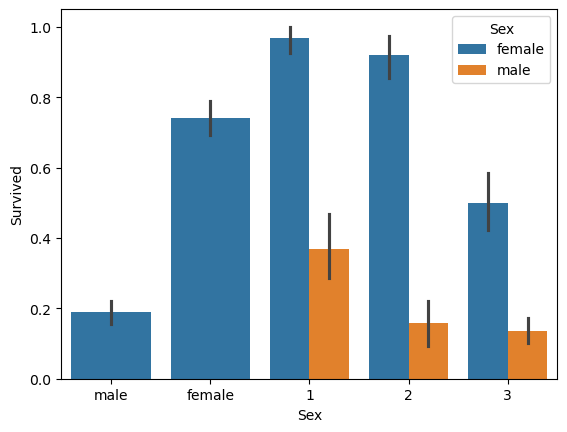

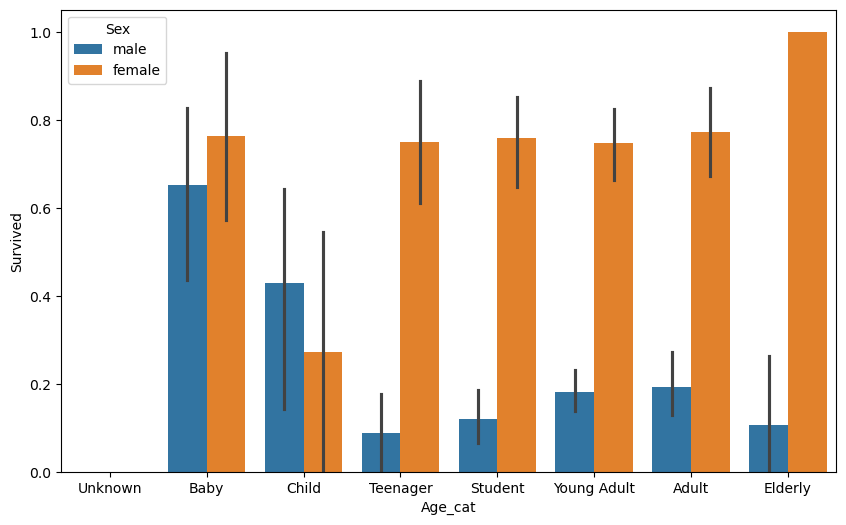

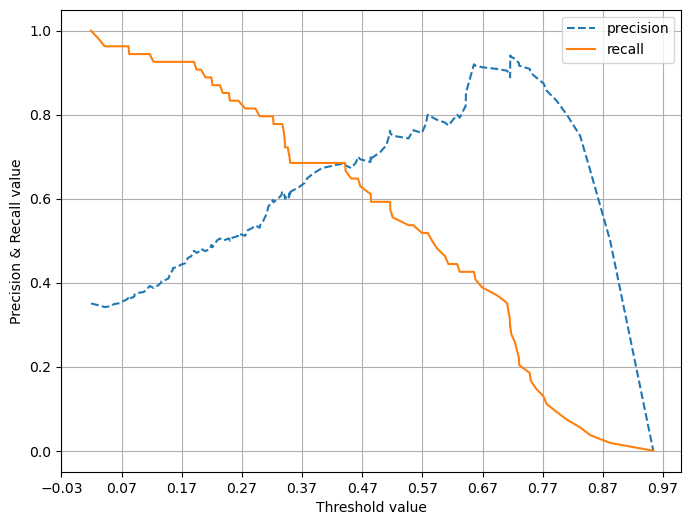

In [124]:
# Checking change of precision & recall values according to thresholds using precision_recall_curve
precision_recall_curve_plot(y_test,pred_proba_c1)
# if we make threshold value to be about 0.42, precision & recall value become balanced to some extent but still at about 0.7

In [125]:
# Before we intentionally fixed threshold value, check data values again
diabetes_df.describe()

# There are so many 0 in min() 
    # it's impossible that glucose value is 0, let's check with histogram

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


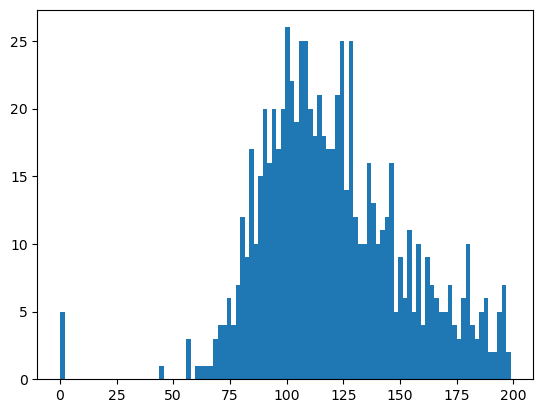

In [126]:
# Histogram for Glucose
# bins : how data is divided into intervals(bins)
    # splits the range of values in diabetes_df['Glucose'] into 100 equal width intervals
    # Glucose range from 50~200 & bins=5
        # 50-80
        # 80 - 110
        # 110 - 140
        # 140 - 170
        # 170 - 200
plt.hist(diabetes_df['Glucose'],bins=100)
plt.show()
# 5 zeros can be found

In [127]:
# Checking # & % of zeros in features that contain 0
# Pregnancies : 출산 횟수여서 제외

# Features that contain 0
zero_features = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
# Total # of elements
total_count = diabetes_df['Glucose'].count()

for feature in zero_features:
    zero_count = diabetes_df[diabetes_df[feature]==0][feature].count()
    print('{0} 0 건수는 {1}, 퍼센트는 {2:.2f}%'.format(feature,zero_count,100*zero_count/total_count))

# SkinThickness & Insulin -> too much 0s 

Glucose 0 건수는 5, 퍼센트는 0.65%
BloodPressure 0 건수는 35, 퍼센트는 4.56%
SkinThickness 0 건수는 227, 퍼센트는 29.56%
Insulin 0 건수는 374, 퍼센트는 48.70%
BMI 0 건수는 11, 퍼센트는 1.43%


In [128]:
# Every row & every column with Glucose 0
diabetes_df[diabetes_df['Glucose']==0]
# Every row & only Glucose column with Glucose 0
diabetes_df[diabetes_df['Glucose']==0]['Glucose']

75     0
182    0
342    0
349    0
502    0
Name: Glucose, dtype: int64

In [129]:
# Replacing 0s with mean value
mean_zero_features = diabetes_df[zero_features].mean()
# mean_zero_features
#     Glucose          120.894531
#     BloodPressure     69.105469
#     SkinThickness     20.536458
#     Insulin           79.799479
#     BMI               31.992578
diabetes_df[zero_features]=diabetes_df[zero_features].replace(0,mean_zero_features)
diabetes_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63,0
764,2,122.0,70.0,27.000000,79.799479,36.8,0.340,27,0
765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30,0
766,1,126.0,60.0,20.536458,79.799479,30.1,0.349,47,1


In [130]:
# Scaling numbers data
# It is good to use scaling on numbers data in LogisticRegression
# Features data
X = diabetes_df.iloc[:,:-1]
# Label data
y = diabetes_df.iloc[:,-1]

# declare standardscaler obj
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [131]:
# LogisticRegression using scaled data

# Split data
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=156,stratify=y)

# create logisticregression obj
lr_clf = LogisticRegression()
# Train
lr_clf.fit(X_train,y_train)
# Predict
pred = lr_clf.predict(X_test)
# Evaluate
pred_proba_c1 = lr_clf.predict_proba(X_test)[:,-1]

get_clf_eval(y_test,pred,pred_proba_c1)
# 데이터 변환과 스케일링을 통해 성능 수치가 일정 수준 개선됨

Confusion Matrix
[[90 10]
 [21 33]]
Accuracy: 0.7987, Precision 0.7674, Recall: 0.6111, F1: 0.6804, AUC: 0.8433


In [137]:
def get_eval_by_threshold(y_test,pred_proba_c1,thresholds):
    for custom_threshold in thresholds:
        # Train
        binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1)
        # Predict 
        custom_predict = binarizer.transform(pred_proba_c1)
        print('임겟값:',custom_threshold)
        # Evaluate
        get_clf_eval(y_test,custom_predict,pred_proba_c1)

In [141]:
# Checking rate of change between metrics according to different thresholds
thresholds = [0.3,0.33,0.36,0.39,0.42,0.45,0.48,0.50]
pred_proba_c1= lr_clf.predict_proba(X_test)[:,-1]
get_eval_by_threshold(y_test,pred_proba_c1.reshape(-1,1),thresholds)

임겟값: 0.3
Confusion Matrix
[[67 33]
 [11 43]]
Accuracy: 0.7143, Precision 0.5658, Recall: 0.7963, F1: 0.6615, AUC: 0.8433
임겟값: 0.33
Confusion Matrix
[[72 28]
 [12 42]]
Accuracy: 0.7403, Precision 0.6000, Recall: 0.7778, F1: 0.6774, AUC: 0.8433
임겟값: 0.36
Confusion Matrix
[[76 24]
 [15 39]]
Accuracy: 0.7468, Precision 0.6190, Recall: 0.7222, F1: 0.6667, AUC: 0.8433
임겟값: 0.39
Confusion Matrix
[[78 22]
 [16 38]]
Accuracy: 0.7532, Precision 0.6333, Recall: 0.7037, F1: 0.6667, AUC: 0.8433
임겟값: 0.42
Confusion Matrix
[[84 16]
 [18 36]]
Accuracy: 0.7792, Precision 0.6923, Recall: 0.6667, F1: 0.6792, AUC: 0.8433
임겟값: 0.45
Confusion Matrix
[[85 15]
 [18 36]]
Accuracy: 0.7857, Precision 0.7059, Recall: 0.6667, F1: 0.6857, AUC: 0.8433
임겟값: 0.48
Confusion Matrix
[[88 12]
 [19 35]]
Accuracy: 0.7987, Precision 0.7447, Recall: 0.6481, F1: 0.6931, AUC: 0.8433
임겟값: 0.5
Confusion Matrix
[[90 10]
 [21 33]]
Accuracy: 0.7987, Precision 0.7674, Recall: 0.6111, F1: 0.6804, AUC: 0.8433


In [142]:
# 임곗값 0.48 
binarizer = Binarizer(threshold=0.48)
pred_th_048 = binarizer.fit_transform(pred_proba_c1.reshape(-1,1))
get_clf_eval(y_test,pred_th_048,pred_proba_c1)

Confusion Matrix
[[88 12]
 [19 35]]
Accuracy: 0.7987, Precision 0.7447, Recall: 0.6481, F1: 0.6931, AUC: 0.8433
